In [1]:
import numpy as np
import h5py
from tqdm import tqdm
dic_akra = "/home/yshi/work/work_gravity/akra_series/"
import sys, os
sys.path.append(dic_akra + 'utils/')
from gaussianfield import get_cl
sys.path.append(dic_akra + 'core/')
from Kappa_Map import KappaMap
import matplotlib.pyplot as plt


In [2]:
nx = 64
ny = 64

/home/yshi/.conda/envs/mypy310/lib/python3.10/site-packages/pyccl/tracers.py:150: CCLWarning: The number of samples in the n(z) (200) is smaller than the number of samples in the lensing kernel (256). Consider disabling spline integration for the lensing kernel by setting pyccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False before instantiating the Cosmology passed.
  warnings.warn(


dx, dy are in arcminutes.


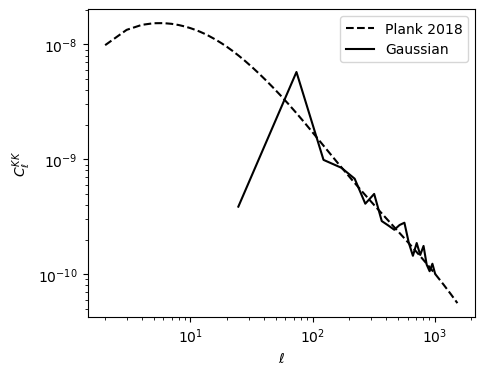

In [3]:
import healpy as hp
import astropy.units as u
from gaussianfield import get_cl, cl2map, map2cl
nside = 512
ell = np.arange(2, 3*nside)
cl_kk = get_cl(ell=ell)
# get resolution
resolution = hp.nside2resol(nside, arcmin=True)
resolution_deg = resolution * u.arcmin.to(u.degree)

# get flatskymapparams
flatskymapparams = [nx, ny, resolution, resolution]
lx, ly, dx, dy = flatskymapparams

# get kappa map
kappa_map = cl2map(flatskymapparams, cl_kk, el = ell)
cl2 = map2cl(flatskymapparams, kappa_map)

# plot 
plt.figure(figsize=(5,4), dpi=100)
plt.loglog(ell, cl_kk, c="black", label="Plank 2018", ls="dashed")
plt.loglog(cl2[0], cl2[1], c="black", label="Gaussian", ls="solid")
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell^{KK}$')
plt.legend()
plt.show()


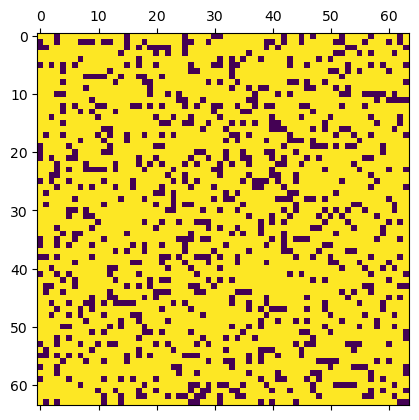

In [4]:
def getMask(lx, ly, percent):
    """
    Generate mask with percent of pixels masked
    """
    mask = np.ones((lx,ly), dtype=np.float32).flatten()
    index = np.random.choice(mask.size, int(percent*mask.size), replace=False)
    mask[index] = 0
    return mask.reshape(lx,ly)
mask = getMask(nx, ny, 0.2)
plt.matshow(mask)

In [14]:
import importlib
importlib.reload(sys.modules['Kappa_Map'])
from Kappa_Map import KappaMap

In [15]:
gamma_1 = np.zeros((nx, ny))
gamma_2 = np.zeros((nx, ny))
kmap = KappaMap(gamma_1, gamma_1, mask=np.ones_like(kappa_map))
gamma10, gamma20 = kmap.kappa2gamma(kappa_map)
print(gamma10.dtype)
del kmap

complex128


In [16]:
gamma1_obs = gamma10 * mask
gamma2_obs = gamma20 * mask

In [17]:
### E mode map

In [18]:
kmap = KappaMap(gamma1_obs, gamma2_obs, mask=mask)
ks_map = kmap.kappa_ks()
akra_map = kmap.kappa_inv()

 .   Calculating the cholesky decomposition of the psf ... 

    Time taken for cholesky decomposition: 5.47 s


In [19]:
ks_sigma = np.abs(ks_map - kappa_map)/np.std(kappa_map)
akra_sigma = np.abs(akra_map - kappa_map)/np.std(kappa_map)

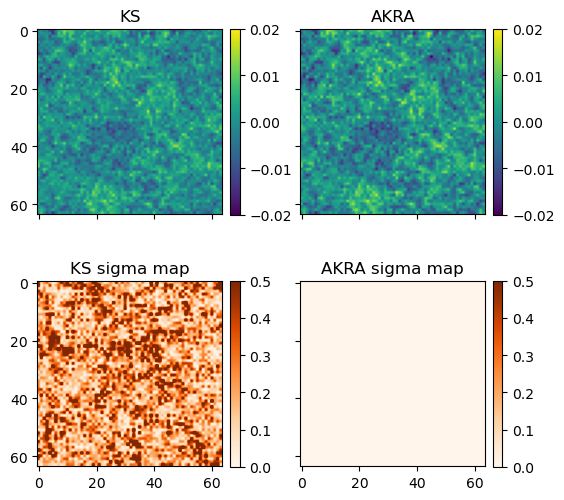

In [20]:
fig, ax = plt.subplots(2,2, figsize=(6,6), dpi=100, sharex=True, sharey=True, gridspec_kw={'wspace':0.3, 'hspace':0.2})
cmap1 = 'viridis'
im0 = ax[0,0].imshow(ks_map, cmap=cmap1, vmin=-0.02, vmax=0.02)
ax[0,0].set_title('KS')
im1 = ax[0,1].imshow(akra_map, cmap=cmap1, vmin=-0.02, vmax=0.02)
ax[0,1].set_title('AKRA')
im2 = ax[1,0].imshow(ks_sigma, cmap='Oranges', vmin=0, vmax=0.5)
ax[1,0].set_title('KS sigma map')
im3 = ax[1,1].imshow(akra_sigma, cmap='Oranges', vmin=0, vmax=0.5)
ax[1,1].set_title('AKRA sigma map')
fig.colorbar(im0, ax=ax[0,0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=ax[0,1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=ax[1,0], fraction=0.046, pad=0.04)
fig.colorbar(im3, ax=ax[1,1], fraction=0.046, pad=0.04)
plt.show()


In [36]:
import importlib
importlib.reload(sys.modules['Kappa_Map'])
from Kappa_Map import KappaMap

In [ ]:
kmap = KappaMap(gamma1_obs, gamma2_obs, mask=mask)
ks_map, ks_Bmap = kmap.kappa_ks(return_B=True)
akra_map, akra_Bmap = kmap.kappa_inv(return_B=True)
ks_Bsigma = np.abs(ks_Bmap)/np.std(kappa_map)
akra_Bsigma = np.abs(akra_Bmap)/np.std(kappa_map)

 .   Calculating the cholesky decomposition of the psf ... 

    Time taken for cholesky decomposition: 4.90 s


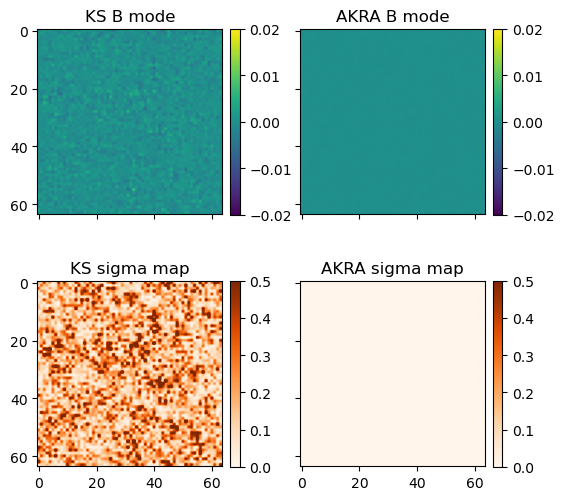

In [39]:
fig, ax = plt.subplots(2,2, figsize=(6,6), dpi=100, sharex=True, sharey=True, gridspec_kw={'wspace':0.3, 'hspace':0.2})
cmap1 = 'viridis'
im0 = ax[0,0].imshow(ks_Bmap, cmap=cmap1, vmin=-0.02, vmax=0.02)
ax[0,0].set_title('KS B mode')
im1 = ax[0,1].imshow(akra_Bmap, cmap=cmap1, vmin=-0.02, vmax=0.02)
ax[0,1].set_title('AKRA B mode')
im2 = ax[1,0].imshow(ks_Bsigma, cmap='Oranges', vmin=0, vmax=0.5)
ax[1,0].set_title('KS sigma map')
im3 = ax[1,1].imshow(akra_Bsigma, cmap='Oranges', vmin=0, vmax=0.5)
ax[1,1].set_title('AKRA sigma map')
fig.colorbar(im0, ax=ax[0,0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=ax[0,1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=ax[1,0], fraction=0.046, pad=0.04)
fig.colorbar(im3, ax=ax[1,1], fraction=0.046, pad=0.04)
plt.show()


In [26]:
kmap.w_k.shape

(8192, 4096)